In [5]:
import pandas as pd 
import matplotlib.pyplot as plt

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn import preprocessing 
import numpy as np

In [7]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

In [8]:
df = pd.read_csv(url)

In [63]:
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,D,E,X,Z
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196,0.0,0.0,0.0,1.0
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221,0.0,0.0,0.0,1.0
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136,0.0,0.0,0.0,1.0
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255,0.0,0.0,0.0,1.0
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244,0.0,0.0,0.0,1.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [48]:
city = df['FUELCONSUMPTION_CITY']
hwy= df['FUELCONSUMPTION_HWY']
comb = df['FUELCONSUMPTION_COMB']
comb_mpg = df['FUELCONSUMPTION_COMB_MPG']

engine_size = df['ENGINESIZE']
co2_emmision = df['CO2EMISSIONS']
cylinder = df['CYLINDERS']

fuel_type = df['FUELTYPE']

Text(0, 0.5, 'CO2 Emmision')

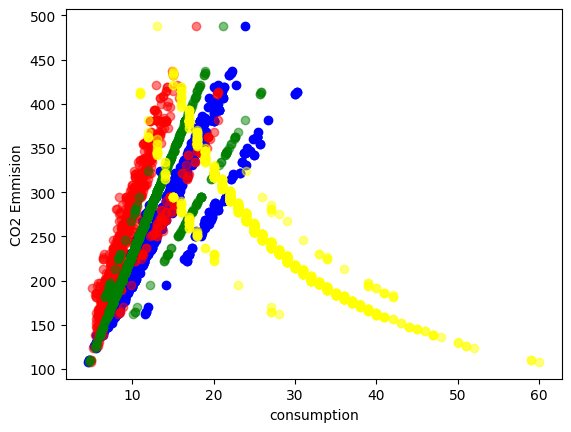

In [72]:
plt.scatter (city , co2_emmision , color = 'blue')
plt.scatter (hwy , co2_emmision , color = 'red' , alpha = 0.5)
plt.scatter (comb , co2_emmision , color = 'green' , alpha = 0.5)
plt.scatter (comb_mpg, co2_emmision , color = 'yellow' , alpha = 0.5)
plt.xlabel('consumption')
plt.ylabel('CO2 Emmision')

Text(0, 0.5, 'co2 emmision')

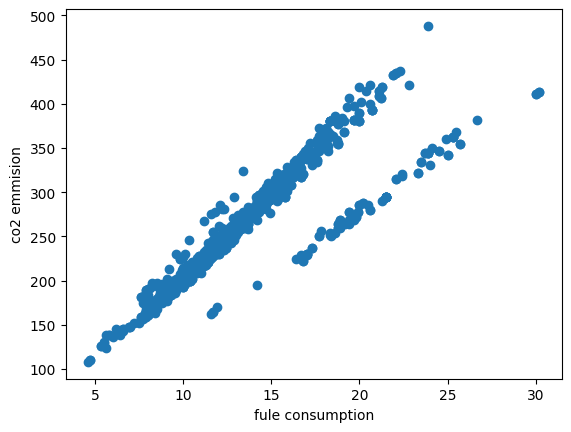

In [35]:
plt.scatter(city , co2_emmision)
plt.xlabel('fule consumption')
plt.ylabel('co2 emmision')

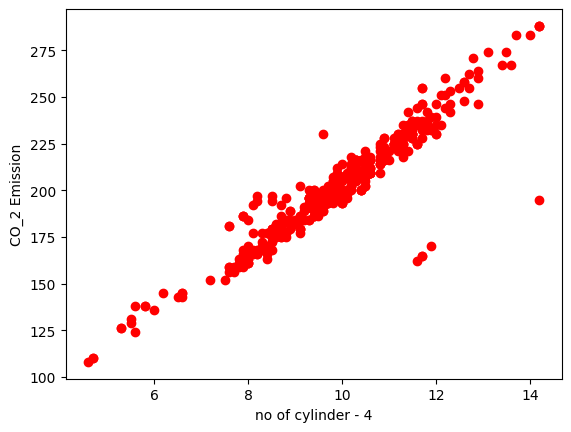

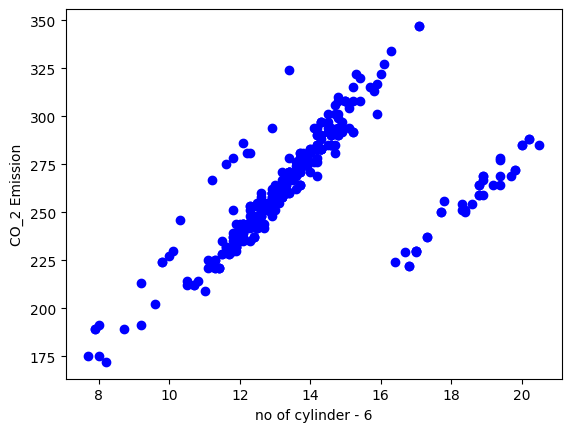

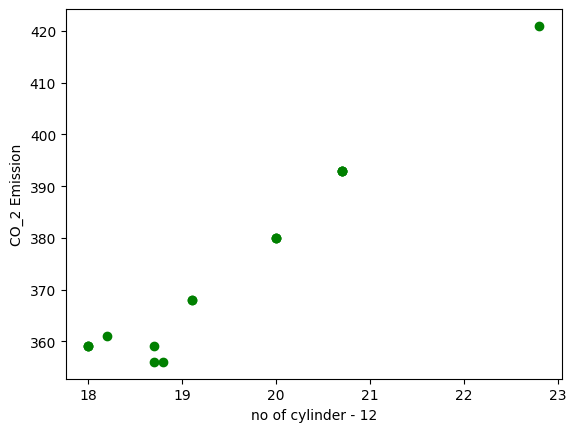

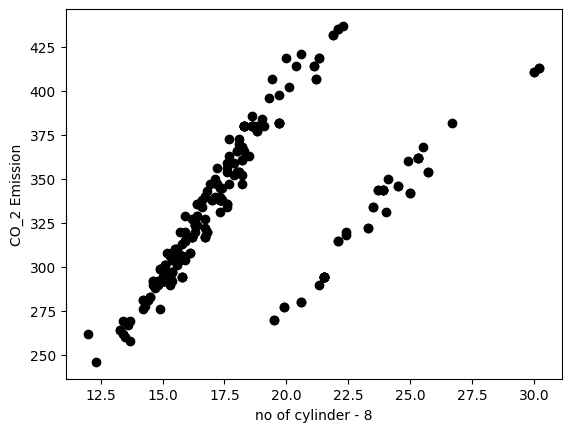

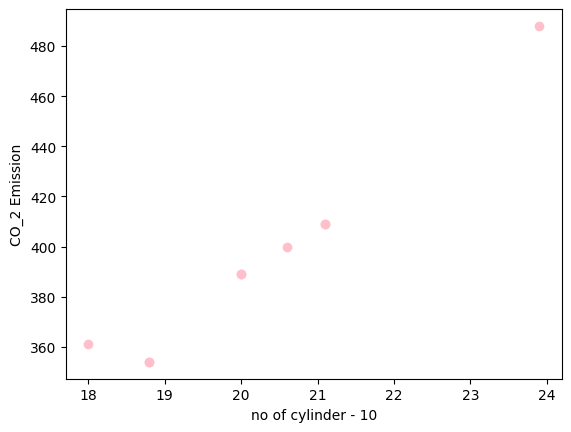

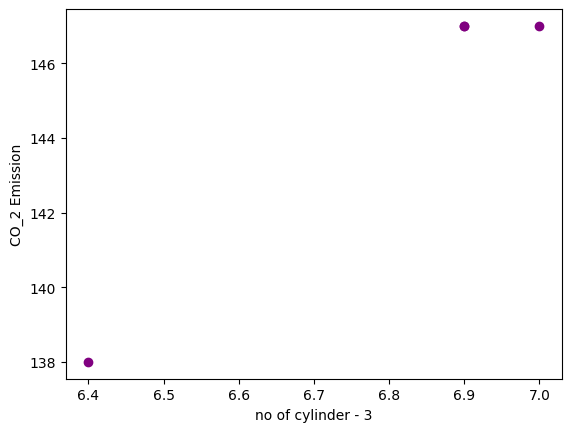

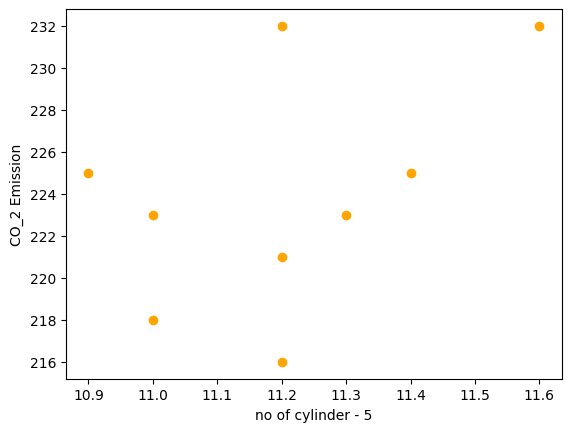

In [73]:
A = { 4: 'red' , 6:'blue' , 12:'green' ,  8 : 'black' ,  10: 'pink' ,   3: 'purple' ,   5: 'orange'}
for vals , color in A.items():
    cyl_size = df[df['CYLINDERS'] == vals]
    plt.scatter(cyl_size['FUELCONSUMPTION_CITY'] , cyl_size['CO2EMISSIONS'] , color = color )
    plt.xlabel(f'no of cylinder - {(vals)}')
    plt.ylabel('CO_2 Emission')
    plt.show()

In [50]:
enc = preprocessing.OneHotEncoder()
enc.fit(df[['FUELTYPE']])
enc.categories_

[array(['D', 'E', 'X', 'Z'], dtype=object)]

In [52]:
one_hot = enc.transform(df[['FUELTYPE']]).toarray()
df[['D', 'E', 'X', 'Z']] = one_hot

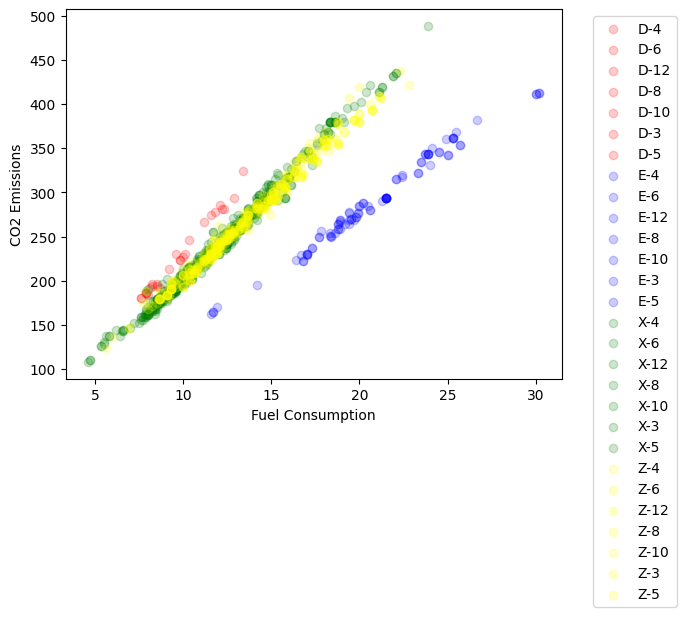

In [58]:
types = { 'red' : 'D', 'blue':'E', 'green': 'X','yellow':'Z'}
cyln = [4, 6, 12, 8, 10, 3, 5]

for col, fuel_type in types.items():
    for i in cyln:
        subset = df[(df['CYLINDERS'] == i) & (df['FUELTYPE'] == fuel_type)]
        plt.scatter(
            subset['FUELCONSUMPTION_CITY'],
            subset['CO2EMISSIONS'],
            color=col,
            alpha=0.2,
            label=f"{fuel_type}-{i}"
        )

plt.xlabel('Fuel Consumption')
plt.ylabel('CO2 Emissions')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

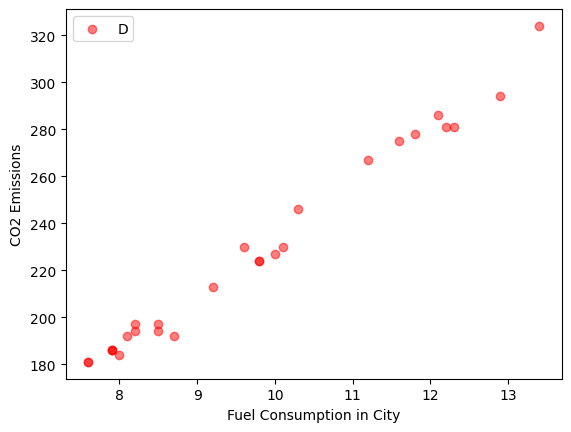

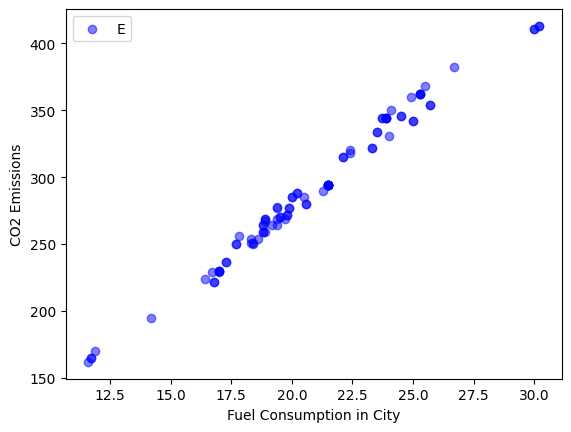

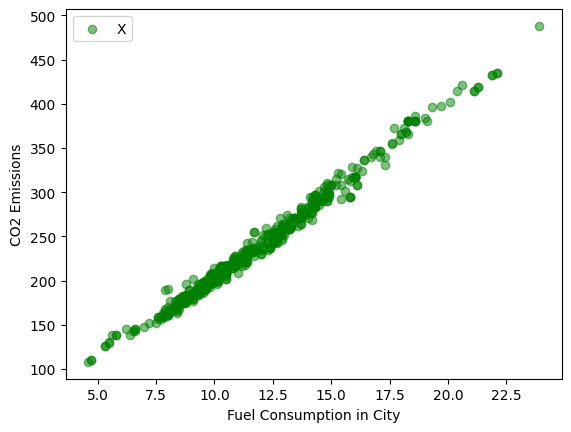

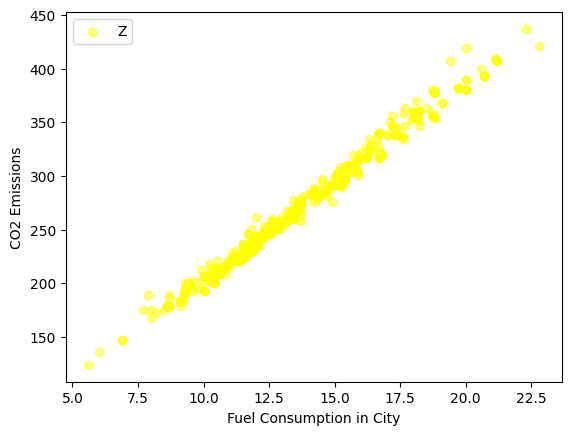

In [69]:
types = { 'red' : 'D', 'blue':'E', 'green': 'X','yellow':'Z'}

for col, fuel_type in types.items():
    subset = df[df['FUELTYPE'] == fuel_type]
        
    plt.scatter(
        subset['FUELCONSUMPTION_CITY'],
        subset['CO2EMISSIONS'],
        color=col,
        alpha=0.5,
        label=fuel_type
    )
    plt.xlabel('Fuel Consumption in City')
    plt.ylabel('CO2 Emissions')
    plt.legend()
    plt.show()